<a href="https://colab.research.google.com/github/cerrutisofi/TP-FINAL-DATOS/blob/main/Presupuesto_Participativo_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Presupuesto Participativo - Vicente López
## Modelo de Clasificación con Random Forest

Este notebook predice si un proyecto del Presupuesto Participativo será **ganador o no**,
usando datos del proyecto cruzados con información del Censo 2022 por localidad.

## 1. Importación de librerías

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Carga de datos

In [23]:
# Dataset principal de proyectos
df = pd.read_csv(
    'https://github.com/cerrutisofi/TP-FINAL-DATOS/raw/refs/heads/main/DATOS/Datos%20procesados/dataset_final_vilo.csv',
    sep=';',
    header=0
)

# Datos del Censo 2022
df_censo_2022 = pd.read_excel(
    'https://github.com/cerrutisofi/TP-FINAL-DATOS/raw/refs/heads/main/DATOS/Datos%20procesados/Censo%202022%20-%20Vicente%20L%C3%B3pez.xlsx'
)

print(f'Proyectos cargados: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Censo cargado:      {df_censo_2022.shape[0]} filas x {df_censo_2022.shape[1]} columnas')

Proyectos cargados: 1528 filas x 7 columnas
Censo cargado:      9 filas x 47 columnas


In [24]:
df.head()

,Año,Localidades,Proyecto,Categoria,Votos,Presupuesto,Ganador_bin
0,2017,Villa Martelli,BOMBEROS VOLUNTARIOS DE VICENTE LÓPEZ - 25 equ...,Seguridad y bomberos,959,978500,1
1,2017,Villa Martelli,CAMPAÑA DE CONCIENTIZACIÓN SOBRE EL BULLYING -...,Educación y escuelas,506,193892,1
2,2017,Villa Martelli,FUNDACION CAMINO - Remodelación interior y fac...,Construcción y reparaciones edilicias,487,1500000,1
3,2017,Villa Martelli,ESCUELA SECUNDARIA Nº 2 (provincial) - Reparac...,Construcción y reparaciones edilicias,482,1200000,1
4,2017,Villa Martelli,BIBLIOTECA FROILÁN GONZÁLEZ - Compra de mobili...,Educación y escuelas,446,132000,1


In [25]:
df_censo_2022.head()

,Municipios,Total poblacional,Localidades,Geolocalización,Límites,Viviendas particulares,Población en viviendas particulares,Mujer/Femenino,Varón/Masculino,0-4,...,No tiene internet en la vivienda,Obra social o\nprepaga\n(incluye PAMI),Programas o\nplanes estatales\nde salud,"No tiene obra\nsocial, prepaga ni\nplan estatal",Población\ncon asistencia escolar,Población\nsin asistencia escolar\npero que si asistió,Población\nque nunca\ntuvo asistencia escolar,Población económicamente activa ocupada,Población económicamente activa desocupada,Población no económicamente activa
0,Vicente López,280541,Carapachay,"-58.5452628,-34.5277154,0.0 -58.5388899,-34.53...",Polygon Outer Boundary,6995,16914,8910,8004,681,...,597,14271,227,2416,5131,11463,320,8507,722,5184
1,Vicente López,280541,Florida Este,"-58.4935926,-34.5466773,0.0 -58.4758687,-34.53...",Polygon Outer Boundary,22270,49536,26765,22771,2083,...,1456,44666,733,4137,15196,32648,1692,25955,2311,14243
2,Vicente López,280541,Florida Oeste,"-58.5288477,-34.539086,0.0 -58.5286761,-34.540...",Polygon Outer Boundary,11524,28227,14713,13514,1268,...,1284,20721,650,6856,9021,18445,761,14289,1237,7936
3,Vicente López,280541,La Lucila,"-58.4974766,-34.4975558,0.0 -58.492949,-34.506...",Polygon Outer Boundary,6321,13554,7236,6318,609,...,341,12426,176,952,4000,8923,631,6897,646,4077
4,Vicente López,280541,Munro,"-58.5248244,-34.5111098,0.0 -58.5308325,-34.51...",Polygon Outer Boundary,14580,34797,18277,16520,1502,...,1548,26894,640,7263,10561,23259,977,17970,1656,9979


## 3. Preprocesamiento de los datos

In [26]:
# Corrección de columnas con valores mixtos en el censo
columnas_a_limpiar = ['Perforación con bomba manual', 'Pozo sin bomba']

for col in columnas_a_limpiar:
    df_censo_2022[col] = (
        pd.to_numeric(df_censo_2022[col], errors='coerce')
          .fillna(0)
          .astype('int64')
    )

print('Columnas del censo corregidas')

Columnas del censo corregidas


In [27]:
# Join entre proyectos y censo por localidad
df_definitivo = pd.merge(df, df_censo_2022, on='Localidades', how='inner')

print(f'Dataset unificado: {df_definitivo.shape[0]} filas x {df_definitivo.shape[1]} columnas')

Dataset unificado: 1528 filas x 53 columnas


In [28]:
# Agrupación de rangos etarios del censo en 3 franjas
df_definitivo['0-14'] = df_definitivo[['0-4','5-9','10-14']].sum(axis=1)

df_definitivo['15-64'] = df_definitivo[[
    '15-19','20-24','25-29','30-34','35-39',
    '40-44','45-49','50-54','55-59','60-64'
]].sum(axis=1)

df_definitivo['65-100 y mas'] = df_definitivo[[
    '65-69','70-74','75-79','80-84','85-89',
    '90-94','95-99','100 y más'
]].sum(axis=1)

# Eliminación de las columnas originales de rango etario
cols_etarias = [
    '0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
    '40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79',
    '80-84','85-89','90-94','95-99','100 y más'
]
df_definitivo.drop(columns=cols_etarias, inplace=True)

# Eliminación de columnas no relevantes para el modelado
cols_a_eliminar = [
    'Proyecto', 'Municipios', 'Geolocalización', 'Límites',
    'Perforación con bomba a motor', 'Perforación con bomba manual',
    'Pozo sin bomba',
    'Transporte por cisterna, agua de lluvia, río, canal, arroyo o acequia',
    'Otra\nprocedencia', 'Tiene internet en la vivienda', 'No tiene internet en la vivienda',
    'Obra social o\nprepaga\n(incluye PAMI)', 'Programas o\nplanes estatales\nde salud',
    'No tiene obra\nsocial, prepaga ni\nplan estatal',
    'Población\nsin asistencia escolar\npero que si asistió',
    'Población\nque nunca\ntuvo asistencia escolar',
    'Población económicamente activa desocupada', 'Población no económicamente activa'
]
df_definitivo.drop(columns=cols_a_eliminar, inplace=True, errors='ignore')

print(f'Dataset final: {df_definitivo.shape[0]} filas x {df_definitivo.shape[1]} columnas')
df_definitivo.info()

Dataset final: 1528 filas x 17 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1528 entries, 0 to 1527
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Año                                      1528 non-null   int64 
 1   Localidades                              1528 non-null   object
 2   Categoria                                1528 non-null   object
 3   Votos                                    1528 non-null   int64 
 4   Presupuesto                              1528 non-null   int64 
 5   Ganador_bin                              1528 non-null   int64 
 6   Total poblacional                        1528 non-null   int64 
 7   Viviendas particulares                   1528 non-null   int64 
 8   Población en viviendas particulares      1528 non-null   int64 
 9   Mujer/Femenino                           1528 non-null   int64 
 10  Varón/Masculino     

In [29]:
df_definitivo.columns.tolist()

['Año',
 'Localidades',
 'Categoria',
 'Votos',
 'Presupuesto',
 'Ganador_bin',
 'Total poblacional',
 'Viviendas particulares',
 'Población en viviendas particulares',
 'Mujer/Femenino',
 'Varón/Masculino',
 'Red pública\n(agua corriente)',
 'Población\ncon asistencia escolar',
 'Población económicamente activa ocupada',
 '0-14',
 '15-64',
 '65-100 y mas']

In [30]:
# Cálculo de tasas sobre la población total
# (se calculan ANTES de eliminar las columnas originales)
pop = df_definitivo['Total poblacional']

df_definitivo['tasa_mujer']          = df_definitivo['Mujer/Femenino']                           / pop
df_definitivo['tasa_varon']          = df_definitivo['Varón/Masculino']                           / pop
df_definitivo['tasa_agua_red']       = df_definitivo['Red pública\n(agua corriente)']              / pop
df_definitivo['tasa_escolaridad']    = df_definitivo['Población\ncon asistencia escolar']          / pop
df_definitivo['tasa_pea_ocupada']    = df_definitivo['Población económicamente activa ocupada']   / pop
df_definitivo['tasa_0_14']           = df_definitivo['0-14']                                      / pop
df_definitivo['tasa_15_64']          = df_definitivo['15-64']                                     / pop
df_definitivo['tasa_65_mas']         = df_definitivo['65-100 y mas']                              / pop

# Eliminación de las variables originales usadas para calcular las tasas
cols_originales_tasas = [
    'Mujer/Femenino', 'Varón/Masculino',
    'Red pública\n(agua corriente)',
    'Población\ncon asistencia escolar',
    'Población económicamente activa ocupada',
    '0-14', '15-64', '65-100 y mas',
    'Total Poblacional'
]
df_definitivo.drop(columns=cols_originales_tasas, inplace=True, errors='ignore')

## 4. Análisis exploratorio

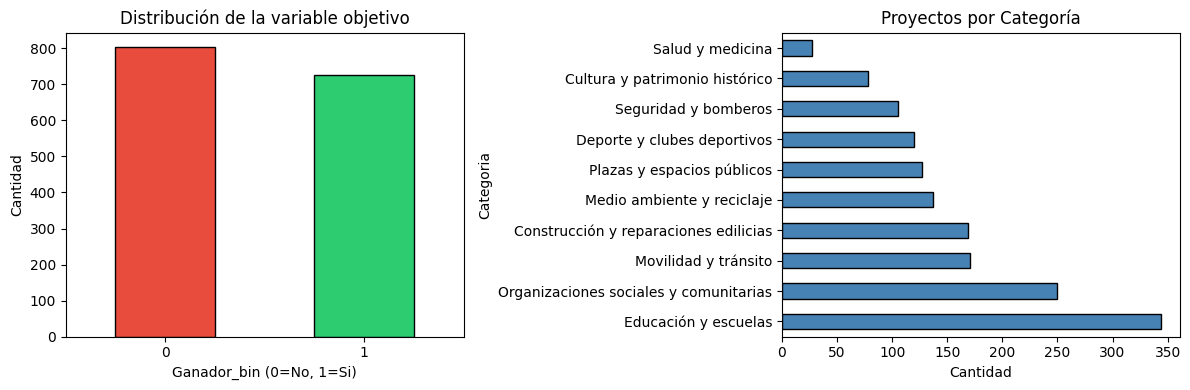

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de la variable objetivo
df_definitivo['Ganador_bin'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[0].set_title('Distribución de la variable objetivo')
axes[0].set_xlabel('Ganador_bin (0=No, 1=Si)')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# Proyectos por categoría
df_definitivo['Categoria'].value_counts().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Proyectos por Categoría')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

## 5. Preparación de features y pipeline

In [32]:
# 'Votos' y 'Año' se eliminan porque no están disponibles al momento de cargar un proyecto nuevo
X = df_definitivo.drop(columns=['Ganador_bin', 'Votos', 'Año'])
y = df_definitivo['Ganador_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')

Train: 1222 muestras | Test: 306 muestras


In [33]:
# Identificación automática de columnas numéricas y categóricas
numeric_features     = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Features numéricas ({len(numeric_features)}):    {numeric_features}')
print(f'Features categóricas ({len(categorical_features)}): {categorical_features}')

Features numéricas (12):    ['Presupuesto', 'Total poblacional', 'Viviendas particulares', 'Población en viviendas particulares', 'tasa_mujer', 'tasa_varon', 'tasa_agua_red', 'tasa_escolaridad', 'tasa_pea_ocupada', 'tasa_0_14', 'tasa_15_64', 'tasa_65_mas']
Features categóricas (2): ['Localidades', 'Categoria']


In [34]:
# Transformadores por tipo de columna
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Pipeline completo con Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('estimator', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

print('Pipeline creado')

Pipeline creado


## 6. Optimización de hiperparámetros con GridSearchCV

In [35]:
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'estimator__n_estimators':              [100, 300, 500],
    'estimator__max_depth':                 [10, 15, 20],
    'estimator__min_samples_leaf':          [1, 2, 5]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gs.fit(X_train, y_train)

print('\nGridSearch finalizado')
print(f'Mejores parámetros: {gs.best_params_}')
print(f'Mejor AUC (CV):     {gs.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits

GridSearch finalizado
Mejores parámetros: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 5, 'estimator__n_estimators': 100, 'preprocessor__num__imputer__strategy': 'mean'}
Mejor AUC (CV):     0.7333


In [36]:
# Top 10 combinaciones de hiperparámetros
cv_results = (
    pd.DataFrame(gs.cv_results_)
      .sort_values('rank_test_score')
      [['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_estimator__n_estimators', 'param_estimator__max_depth',
        'param_estimator__min_samples_leaf',
        'param_preprocessor__num__imputer__strategy']]
      .rename(columns={
          'mean_test_score': 'AUC_medio',
          'std_test_score':  'AUC_std'
      })
)
cv_results.head(10)

,rank_test_score,AUC_medio,AUC_std,param_estimator__n_estimators,param_estimator__max_depth,param_estimator__min_samples_leaf,param_preprocessor__num__imputer__strategy
12,1,0.733315,0.047232,100,10,5,mean
13,1,0.733315,0.047232,100,10,5,median
48,3,0.732473,0.049399,100,20,5,mean
49,3,0.732473,0.049399,100,20,5,median
30,5,0.732273,0.049513,100,15,5,mean
31,5,0.732273,0.049513,100,15,5,median
17,7,0.731462,0.048915,500,10,5,median
16,7,0.731462,0.048915,500,10,5,mean
14,9,0.731122,0.050227,300,10,5,mean
15,9,0.731122,0.050227,300,10,5,median


## 7. Evaluación del modelo final

In [37]:
modelo_final = gs.best_estimator_

y_pred      = modelo_final.predict(X_test)
y_pred_prob = modelo_final.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy en test: {accuracy:.4f}')
print(f'AUC en test:      {auc:.4f}')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=['No Ganador', 'Ganador']))

Accuracy en test: 0.7451
AUC en test:      0.7976

Reporte de clasificación:
              precision    recall  f1-score   support

  No Ganador       0.75      0.77      0.76       161
     Ganador       0.74      0.72      0.73       145

    accuracy                           0.75       306
   macro avg       0.74      0.74      0.74       306
weighted avg       0.74      0.75      0.74       306



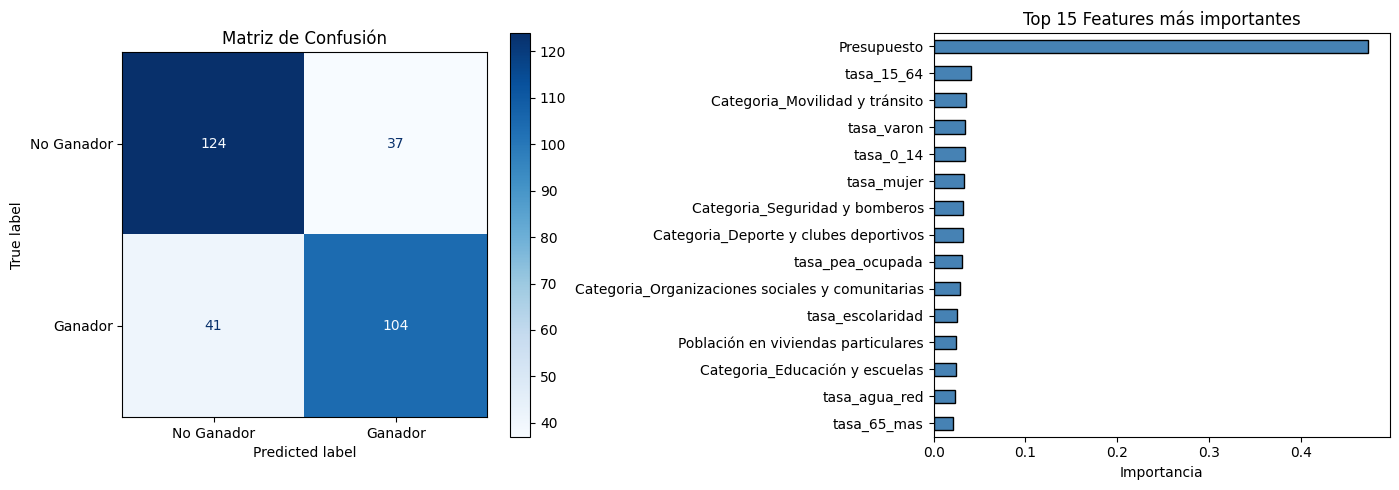

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Ganador', 'Ganador'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')

# Importancia de features (top 15)
rf_model             = modelo_final.named_steps['estimator']
preprocessor_fitted  = modelo_final.named_steps['preprocessor']

cat_feature_names = (
    preprocessor_fitted
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + cat_feature_names

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names)
top15 = importances.nlargest(15)

top15.sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 15 Features más importantes')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

## 8. Función de predicción para nuevos proyectos

In [39]:
def _agrupar_rangos_etarios(df):
    """
    Aplica el mismo agrupamiento de rangos etarios que se hizo
    durante el preprocesamiento del dataset de entrenamiento.
    Modifica el DataFrame in-place y retorna el DataFrame.
    """
    df['0-14'] = df[['0-4','5-9','10-14']].sum(axis=1)

    df['15-64'] = df[[
        '15-19','20-24','25-29','30-34','35-39',
        '40-44','45-49','50-54','55-59','60-64'
    ]].sum(axis=1)

    df['65-100 y mas'] = df[[
        '65-69','70-74','75-79','80-84','85-89',
        '90-94','95-99','100 y más'
    ]].sum(axis=1)

    cols_etarias = [
        '0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
        '40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79',
        '80-84','85-89','90-94','95-99','100 y más'
    ]
    df.drop(columns=cols_etarias, inplace=True)
    return df


def _calcular_tasas(df):
    """
    Calcula las tasas poblacionales sobre Total Poblacional y elimina
    las columnas originales utilizadas, replicando el preprocesamiento
    del entrenamiento.
    """
    pop = df['Total poblacional']

    df['tasa_mujer']       = df['Mujer/Femenino']                           / pop
    df['tasa_varon']       = df['Varón/Masculino']                           / pop
    df['tasa_agua_red']    = df['Red pública\n(agua corriente)']              / pop
    df['tasa_escolaridad'] = df['Población\ncon asistencia escolar']          / pop
    df['tasa_pea_ocupada'] = df['Población económicamente activa ocupada']   / pop
    df['tasa_0_14']        = df['0-14']                                      / pop
    df['tasa_15_64']       = df['15-64']                                     / pop
    df['tasa_65_mas']      = df['65-100 y mas']                              / pop

    cols_originales = [
        'Mujer/Femenino', 'Varón/Masculino',
        'Red pública\n(agua corriente)',
        'Población\ncon asistencia escolar',
        'Población económicamente activa ocupada',
        '0-14', '15-64', '65-100 y mas',
        'Total Poblacional'
    ]
    df.drop(columns=[c for c in cols_originales if c in df.columns], inplace=True)
    return df


def predecir_aprobacion(localidad, categoria, presupuesto,
                         modelo, df_censo):
    """
    Predice si un nuevo proyecto del Presupuesto Participativo será ganador.

    Parámetros
    ----------
    localidad  : str   - Nombre de la localidad (debe coincidir con df_censo).
    categoria  : str   - Categoría del proyecto (ej. 'Seguridad', 'Educación').
    presupuesto: float - Monto estimado del proyecto en pesos.
    modelo     : Pipeline sklearn ya entrenado.
    df_censo   : DataFrame del Censo 2022 ORIGINAL (con columnas etarias sin agrupar).

    Retorna
    -------
    dict con prediccion (0/1), etiqueta y probabilidad de éxito.
    """
    nuevo_proy = pd.DataFrame({
        'Localidades': [localidad],
        'Categoria':   [categoria],
        'Presupuesto': [presupuesto]
    })

    # Merge con el censo original (con columnas etarias sin agrupar)
    nuevo_completo = pd.merge(nuevo_proy, df_censo, on='Localidades', how='left')

    if nuevo_completo['Localidades'].isnull().all():
        raise ValueError(
            f"La localidad '{localidad}' no se encontró en el censo. "
            "Verificá la ortografía y los acentos."
        )

    # Aplicar el mismo preprocesamiento de rangos etarios del entrenamiento
    nuevo_completo = _agrupar_rangos_etarios(nuevo_completo)

    # Calcular tasas poblacionales (igual que en el entrenamiento)
    nuevo_completo = _calcular_tasas(nuevo_completo)

    # Eliminar columnas que se sacaron durante el entrenamiento
    cols_a_eliminar = [
        'Municipios', 'Geolocalización', 'Límites',
        'Perforación con bomba a motor', 'Perforación con bomba manual',
        'Pozo sin bomba',
        'Transporte por cisterna, agua de lluvia, río, canal, arroyo o acequia',
        'Otra procedencia', 'Tiene internet en la vivienda', 'No tiene internet en la vivienda',
        'Obra social o prepaga (incluye PAMI)', 'Programas o planes estatales de salud',
        'No tiene obra social, prepaga ni plan estatal',
        'Población sin asistencia escolar pero que si asistió',
        'Población que nunca tuvo asistencia escolar',
        'Población económicamente activa desocupada', 'Población no económicamente activa'
    ]
    nuevo_completo.drop(
        columns=[c for c in cols_a_eliminar if c in nuevo_completo.columns],
        inplace=True
    )

    prediccion   = modelo.predict(nuevo_completo)[0]
    probabilidad = modelo.predict_proba(nuevo_completo)[0][1]
    etiqueta     = 'GANADOR' if prediccion == 1 else 'NO GANADOR'

    print(f'Proyecto: {categoria} | {localidad} | ${presupuesto:,.0f}')
    print(f'Resultado:             {etiqueta}')
    print(f'Probabilidad de exito: {probabilidad:.2%}')

    return {'prediccion': int(prediccion), 'etiqueta': etiqueta, 'probabilidad': probabilidad}


# --- Ejemplo de uso ---
resultado = predecir_aprobacion(
    localidad='Olivos',
    categoria='Seguridad',
    presupuesto=5_000_000,
    modelo=modelo_final,
    df_censo=df_censo_2022   # Pasar el censo ORIGINAL, antes del preprocesamiento
)

Proyecto: Seguridad | Olivos | $5,000,000
Resultado:             NO GANADOR
Probabilidad de exito: 33.49%


## 9. Exportación del modelo

In [40]:
joblib.dump(modelo_final, 'modelo_presupuesto_participativo.pkl')
print('Modelo exportado como modelo_presupuesto_participativo.pkl')

# Para cargarlo en el futuro:
# modelo_cargado = joblib.load('modelo_presupuesto_participativo.pkl')

Modelo exportado como modelo_presupuesto_participativo.pkl
